<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
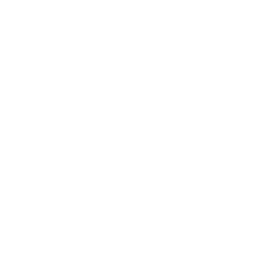
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Κίνδυνος Αναθεώρησης Αρθροπλαστικής με Μεσοδιαστηματική Λογοκρισία</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Αποτελέσματα Ορθοπεδικής Χειρουργικής &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

## Περίληψη

Η ετήσια ακτινολογική παρακολούθηση ανιχνεύει την αστοχία της πρόθεσης μόνο μεταξύ επισκέψεων, οπότε κάθε χρόνος αναθεώρησης είναι **μεσοδιαστηματικά λογοκριμένος** (interval-censored): γνωρίζουμε μόνο ότι βρίσκεται ανάμεσα στην τελευταία καθαρή επίσκεψη και την πρώτη επίσκεψη στην οποία υποδεικνύεται αναθεώρηση. Αυτή η μελέτη προσαρμόζει ένα μοντέλο αναλογικών κινδύνων με την `PROC ICPHREG` σε ένα μητρώο 100 αντικαταστάσεων ισχίου και γόνατος και ποσοτικοποιεί πώς το υλικό της αρθρικής επιφάνειας, ο ΔΜΣ του ασθενούς, η άρθρωση, και η χειρουργική προσπέλαση επηρεάζουν τον κίνδυνο αναθεώρησης.

Το προσαρμοσμένο μοντέλο αναδεικνύει το υλικό της αρθρικής επιφάνειας και τον ΔΜΣ ως τους κυρίαρχους παράγοντες κινδύνου. Σε σχέση με την τιμή αναφοράς κεραμικό-σε-κεραμικό, τα εμφυτεύματα μέταλλο-σε-πολυαιθυλένιο φέρουν **3.29 φορές κίνδυνο αναθεώρησης** (95% ΔΕ 1.76-6.16, p=0.0002), και κάθε επιπλέον μονάδα ΔΜΣ αυξάνει τον κίνδυνο κατά **11%** (HR 1.11, 95% ΔΕ 1.05-1.18, p=0.0005). Οι αντικαταστάσεις γόνατος τείνουν προς υψηλότερο κίνδυνο αναθεώρησης σε σχέση με το ισχίο (HR 1.55, p=0.057). Η ηλικία, το φύλο, και η χειρουργική προσπέλαση δεν δείχνουν σημαντική συσχέτιση. Αυτά τα αποτελέσματα υποστηρίζουν την προτίμηση κεραμικών αρθρικών επιφανειών και τη βελτιστοποίηση βάρους για ασθενείς με αυξημένο κίνδυνο φθοράς.


## Πηγές Δεδομένων

| Σύνολο Δεδομένων | Ν | Περιγραφή |
|---------|---|-------------|
| joint_registry | 100 | Προσομοιωμένο μητρώο αρθροπλαστικής με ετήσια παρακολούθηση· ο χρόνος αναθεώρησης κάθε εμφυτεύματος είναι μεσοδιαστηματικά λογοκριμένος ανάμεσα στην τελευταία καθαρή επίσκεψη (`last_ok_years`) και την πρώτη επίσκεψη που υποδεικνύει αναθεώρηση (`first_revision_years`). |

Η κοόρτη παράγεται με έναν γνωστό μηχανισμό δημιουργίας δεδομένων, ώστε οι λόγοι κινδύνου (hazard ratios) που ανακτά το μοντέλο να μπορούν να ελεγχθούν έναντι των εγκατεστημένων επιδράσεων. Ένας λανθάνων χρόνος αναθεώρησης προέρχεται από εκθετική κατανομή της οποίας ο ρυθμός αυξάνεται με εμφυτεύματα μέταλλο-σε-πολυαιθυλένιο, υψηλότερο ΔΜΣ, και άρθρωση γόνατος, και στη συνέχεια στρογγυλοποιείται στο ετήσιο πλέγμα επισκέψεων ώστε να προκύψει γνήσια μεσοδιαστηματική λογοκρισία.


---

In [1]:
/* Μητρώο αρθροπλαστικής με ετήσια παρακολούθηση.
   Κάθε εμφύτευμα εξετάζεται μία φορά τον χρόνο· μια αναθεώρηση παρατηρείται
   μόνο ότι βρίσκεται ανάμεσα στην τελευταία καθαρή επίσκεψη και την πρώτη
   αποτυχημένη επίσκεψη, παράγοντας μεσοδιαστηματικά λογοκριμένο χρόνο έως
   την αναθεώρηση. Ένας γνωστός μηχανισμός δημιουργίας μας επιτρέπει να
   επικυρώσουμε τους ανακτημένους λόγους κινδύνου.
   ΣΗΜΕΙΩΣΗ: οι τιμές joint/prosthesis/approach παραμένουν ASCII σκόπιμα
   -- η PROC ICPHREG είναι οικογένειας GLM (μηχανή προσαρμογής μοντέλου
   σχεδιασμού) και δεν επεξεργάζεται σωστά μη-ASCII επίπεδα CLASS· η
   επικεφαλίδα στήλης τους μεταφράζεται αντ' αυτού μέσω δήλωσης LABEL. */
ΔΕΔΟΜΕΝΑ joint_registry;
    CALL streaminit(20260311);
    ARRAY materials[3] $10 ('CeramCeram' 'CeramPoly' 'MetalPoly');
    ARRAY approaches[2] $10 ('Anterior' 'Posterior');
    max_followup = 12;            /* 12 ετήσιες επισκέψεις παρακολούθησης */
    ΕΠΑΝΑΛΗΨΗ patient_id = 1 ΕΩΣ 100;
        joint      = ifc(rand('uniform') < 0.5, 'Hip', 'Knee');
        prosthesis = materials[ rand('integer', 1, 3) ];
        approach   = approaches[ rand('integer', 1, 2) ];
        age_surgery = round(60 + rand('normal') * 9);
        bmi         = round(28 + rand('normal') * 4, 0.1);
        female      = (rand('uniform') < 0.55);

        /* Λογάριθμος κινδύνου: η φθορά μέταλλο-σε-πολυαιθυλένιο είναι η
           χειρότερη, το κεραμικό-σε-κεραμικό το καλύτερο· η παχυσαρκία
           και οι νεότεροι, πιο δραστήριοι ασθενείς αυξάνουν τον κίνδυνο. */
        eta = 0.85 * (prosthesis = 'MetalPoly')
            + 0.40 * (prosthesis = 'CeramPoly')
            + 0.06 * (bmi - 28)
            - 0.02 * (age_surgery - 60)
            + 0.30 * (joint = 'Knee');

        /* Λανθάνων χρόνος αναθεώρησης ~ Εκθετική(ρυθμός = exp(eta)/8). */
        rate   = EXP(eta) / 8;
        latent = -LOG(rand('uniform')) / rate;

        /* Στρογγυλοποίηση στο ετήσιο πλέγμα επισκέψεων: μαθαίνουμε μόνο
           τις οριακές επισκέψεις (τελευταία καθαρή, πρώτη αποτυχημένη). */
        ΕΑΝ latent > max_followup ΤΟΤΕ ΕΠΑΝΑΛΗΨΗ;
            last_ok_years        = max_followup;   /* καθαρή στην τελευταία επίσκεψη */
            first_revision_years = .;              /* δεξιά λογοκριμένο */
            revised = 0;
        ΤΕΛΟΣ;
        ΑΛΛΙΩΣ ΕΠΑΝΑΛΗΨΗ;
            last_ok_years        = floor(latent);  /* τελευταία καθαρή επίσκεψη */
            first_revision_years = ceil(latent);   /* πρώτη αποτυχημένη επίσκεψη */
            ΕΑΝ first_revision_years = last_ok_years ΤΟΤΕ
                first_revision_years = last_ok_years + 1;
            ΕΑΝ last_ok_years = 0 ΤΟΤΕ last_ok_years = .;  /* αριστερά λογοκριμένο */
            revised = 1;
        ΤΕΛΟΣ;
        ΕΞΟΔΟΣ;
    ΤΕΛΟΣ;
    ΚΡΑΤΗΣΗ patient_id joint prosthesis approach age_surgery bmi female
         last_ok_years first_revision_years revised;
ΕΚΤΕΛΕΣΗ;



NOTE: DATA joint_registry


NOTE: Wrote joint_registry (100 rows, 10 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds


---

                                                   The FREQ Procedure

Table of Άρθρωση by Υλικό Αρθρικής Επιφάνειας

Άρθρωση        |CeramCeram | CeramPoly | MetalPoly |      Total
---------------+-----------+-----------+-----------+-----------
Hip            |        13 |        19 |        13 |         45
---------------+-----------+-----------+-----------+-----------
Knee           |        11 |        27 |        17 |         55
---------------+-----------+-----------+-----------+-----------
Total          |        24 |        46 |        30 |        100




NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_joint_prosthesis.spec.json
NOTE: PROC FREQ statement used.


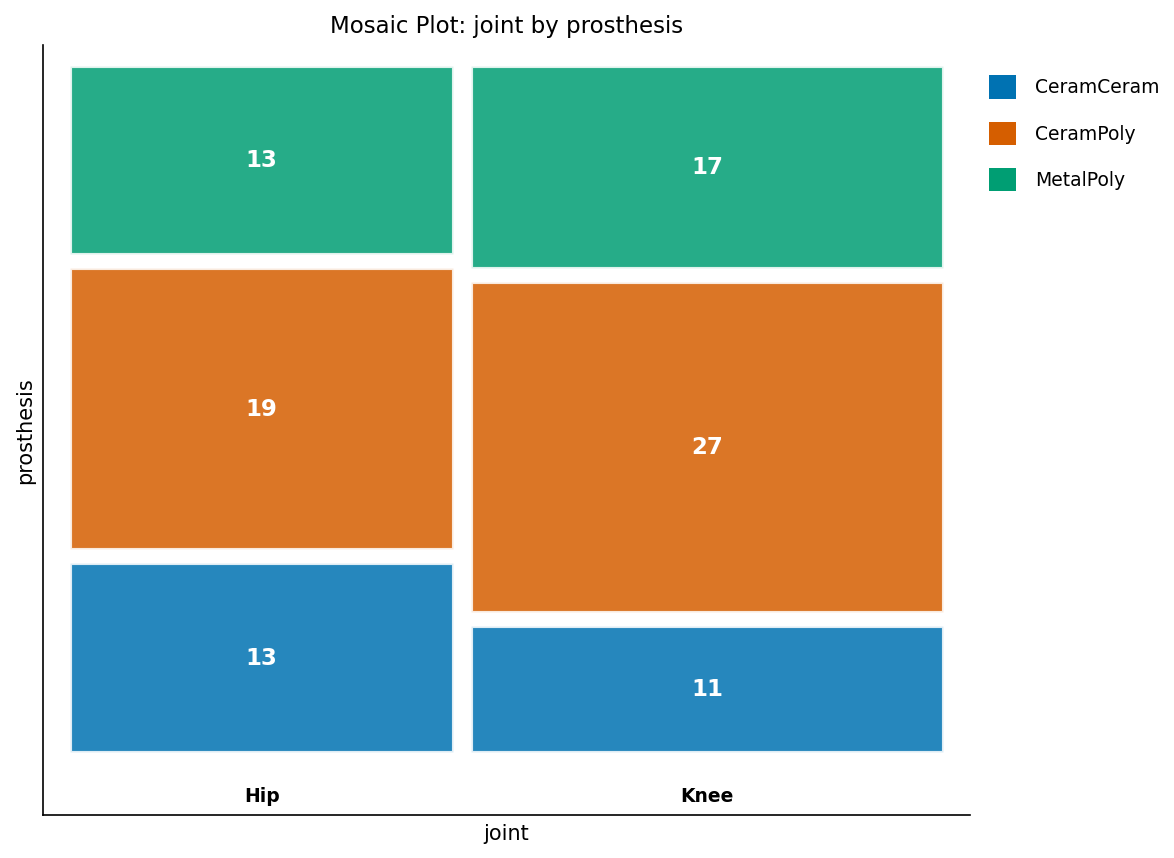

In [2]:
/* Σύνθεση δείγματος: υλικό αρθρικής επιφάνειας ανά άρθρωση */
ΔΙΑΔΙΚΑΣΙΑ ΣΥΧΝΟΤΗΤΕΣ ΔΕΔΟΜΕΝΑ=joint_registry;
    TABLES joint * prosthesis / nocum nopercent;
    ΕΤΙΚΕΤΑ joint='Άρθρωση' prosthesis='Υλικό Αρθρικής Επιφάνειας';
ΕΚΤΕΛΕΣΗ;


---


NOTE: DATA revised_only


NOTE: Read 100 rows from joint_registry.
NOTE: Wrote revised_only (90 rows, 11 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC SGPLOT data=revised_only

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


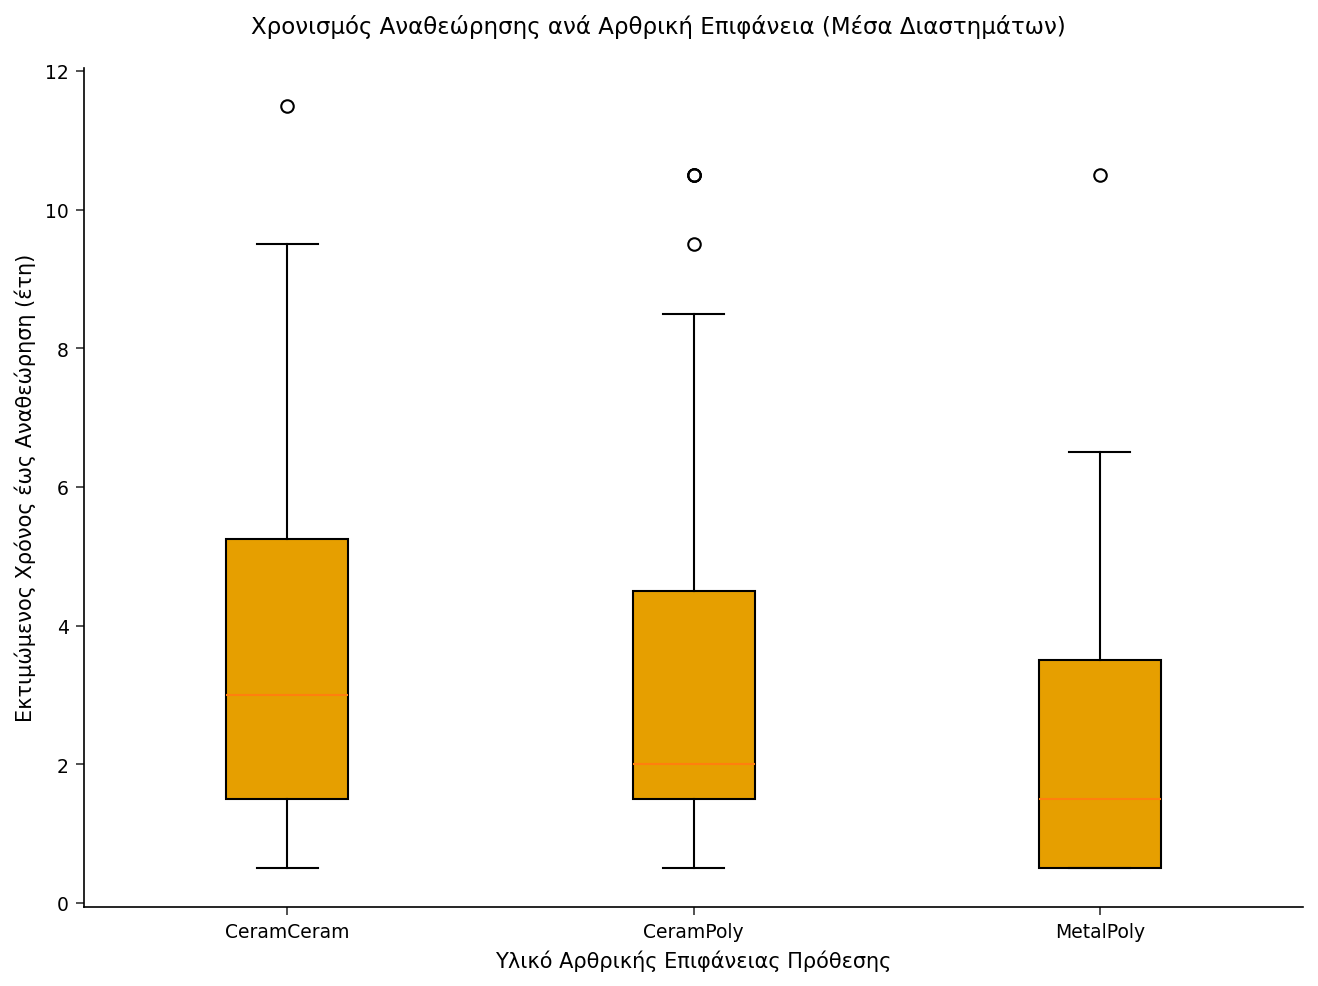

In [3]:
/* Απεικόνιση της εγκατεστημένης επίδρασης που θα ποσοτικοποιήσει το
   μοντέλο: εκτιμώμενος χρόνος έως αναθεώρηση (μέσο διαστήματος) ανά
   αρθρική επιφάνεια, για εμφυτεύματα που αναθεωρήθηκαν εντός της
   παρακολούθησης. */
ΔΕΔΟΜΕΝΑ revised_only;
    ΟΡΙΣΜΟΣ joint_registry;
    ΟΠΟΥ revised = 1 AND first_revision_years ne .;
    ΕΑΝ last_ok_years = . ΤΟΤΕ mid = first_revision_years / 2;
    ΑΛΛΙΩΣ mid = (last_ok_years + first_revision_years) / 2;
    ΕΤΙΚΕΤΑ mid='Εκτιμώμενος Χρόνος έως Αναθεώρηση (έτη)';
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ SGPLOT ΔΕΔΟΜΕΝΑ=revised_only;
    VBOX mid / category=prosthesis;
    XAXIS ΕΤΙΚΕΤΑ='Υλικό Αρθρικής Επιφάνειας Πρόθεσης';
    YAXIS ΕΤΙΚΕΤΑ='Εκτιμώμενος Χρόνος έως Αναθεώρηση (έτη)';
    TITLE 'Χρονισμός Αναθεώρησης ανά Αρθρική Επιφάνεια (Μέσα Διαστημάτων)';
ΕΚΤΕΛΕΣΗ;


---

In [4]:
/* Μοντέλο αναλογικών κινδύνων για μεσοδιαστηματικά λογοκριμένο χρόνο
   αναθεώρησης. Το backend Python (lifelines) χειρίζεται τα όρια
   διαστήματος μέσω προσέγγισης με το μέσο σημείο (midpoint imputation)·
   το κεραμικό-σε-κεραμικό είναι το επίπεδο αναφοράς. */
ΔΙΑΔΙΚΑΣΙΑ ICPHREG ΔΕΔΟΜΕΝΑ=joint_registry wrapper=python;
    ΚΛΑΣΗ joint prosthesis approach;
    ΜΟΝΤΕΛΟ (last_ok_years, first_revision_years) =
          joint prosthesis approach age_surgery bmi female;
    hazardratio prosthesis / DIFF=REF;
    ΕΤΙΚΕΤΑ joint='Άρθρωση' prosthesis='Υλικό Αρθρικής Επιφάνειας'
          approach='Χειρουργική Προσπέλαση' age_surgery='Ηλικία κατά την Εγχείρηση'
          bmi='ΔΜΣ' female='Γυναίκα';
ΕΚΤΕΛΕΣΗ;



      The ICPHREG Procedure

       Model Information
Item                          Value
-------------------------  ------------
Data Set                   JOINT_REGISTRY
Left Truncation Variable   last_ok_years
Right Censoring Variable   first_revision_years
Baseline Hazard            Cubic Splines
Number of Observations          100
Number Right-Censored            10
Number Left-Censored             25
Number Interval-Censored         65

        Fit Statistics
---------------------------------
Log Likelihood            -334.8773
-2 Log Likelihood          669.7546

      Analysis of Maximum Likelihood Parameter Estimates
Parameter         DF  Estimate  Std Error  ChiSq  Pr > ChiSq  Hazard Ratio
-----------------  --  --------  ---------  -----  ----------  ------------
Ηλικία κατά την Εγχείρηση  1   -0.0059     0.0124   0.23      0.6346        0.9941
ΔΜΣ                1    0.1049     0.0302  12.11      0.0005        1.1106
Γυναίκα            1   -0.1124     0.2402   0.22      0.


NOTE: PROC ICPHREG data=joint_registry

NOTE: PROC ICPHREG using Python wrapper
NOTE: PROC ICPHREG spec written to: ./ods_output/icphreg_basic.spec.json


In [5]:
/* Φειδωλό επιβεβαιωτικό μοντέλο: επιμένει η επίδραση της αρθρικής
   επιφάνειας μετά την προσαρμογή μόνο για τον άλλο κυρίαρχο παράγοντα
   κινδύνου (ΔΜΣ) και την άρθρωση; */
ΔΙΑΔΙΚΑΣΙΑ ICPHREG ΔΕΔΟΜΕΝΑ=joint_registry wrapper=python;
    ΚΛΑΣΗ prosthesis;
    ΜΟΝΤΕΛΟ (last_ok_years, first_revision_years) = prosthesis bmi joint;
    hazardratio prosthesis / DIFF=REF;
    ΕΤΙΚΕΤΑ prosthesis='Υλικό Αρθρικής Επιφάνειας' bmi='ΔΜΣ' joint='Άρθρωση';
ΕΚΤΕΛΕΣΗ;



      The ICPHREG Procedure

       Model Information
Item                          Value
-------------------------  ------------
Data Set                   JOINT_REGISTRY
Left Truncation Variable   last_ok_years
Right Censoring Variable   first_revision_years
Baseline Hazard            Cubic Splines
Number of Observations          100
Number Right-Censored            10
Number Left-Censored             25
Number Interval-Censored         65

        Fit Statistics
---------------------------------
Log Likelihood            -335.6106
-2 Log Likelihood          671.2212

      Analysis of Maximum Likelihood Parameter Estimates
Parameter         DF  Estimate  Std Error  ChiSq  Pr > ChiSq  Hazard Ratio
-----------------  --  --------  ---------  -----  ----------  ------------
ΔΜΣ                1    0.1037     0.0296  12.29      0.0005        1.1093
PROSTHESIS_CERAMPOLY  1    0.5655     0.2864   3.90      0.0483        1.7604
PROSTHESIS_METALPOLY  1    1.2466     0.3163  15.54      <.00


NOTE: PROC ICPHREG data=joint_registry

NOTE: PROC ICPHREG using Python wrapper
NOTE: PROC ICPHREG spec written to: ./ods_output/icphreg_basic.spec.json


---

### Ευρήματα Αναθεώρησης Αρθροπλαστικής

Όλοι οι αριθμοί παρακάτω διαβάζονται απευθείας από την προσαρμοσμένη έξοδο της `PROC ICPHREG` παραπάνω.

- **Η αρθρική επιφάνεια κυριαρχεί.** Τα εμφυτεύματα μέταλλο-σε-πολυαιθυλένιο φέρουν **3.29 φορές** κίνδυνο αναθεώρησης σε σχέση με την τιμή αναφοράς κεραμικό-σε-κεραμικό (95% ΔΕ 1.76-6.16, ChiSq 13.93, p=0.0002). Το κεραμικό-σε-πολυαιθυλένιο βρίσκεται ενδιάμεσα στο **1.68 φορές** (95% ΔΕ 0.95-2.97, p=0.075).
- **Ο ΔΜΣ έχει σημασία.** Κάθε επιπλέον μονάδα ΔΜΣ πολλαπλασιάζει τον κίνδυνο αναθεώρησης κατά **1.11** (95% ΔΕ 1.05-1.18, ChiSq 12.11, p=0.0005), οπότε μια διαφορά ΔΜΣ 10 μονάδων περίπου **τριπλασιάζει** τον κίνδυνο.
- **Άρθρωση.** Οι αντικαταστάσεις γόνατος τείνουν προς υψηλότερο κίνδυνο αναθεώρησης σε σχέση με το ισχίο (HR **1.55**, 95% ΔΕ 0.99-2.44, p=0.057) -- ενδεικτικό αλλά όχι αδιαμφισβήτητο σε αυτό το μέγεθος δείγματος.
- **Καμία επίδραση δεν εντοπίστηκε** για τη χειρουργική προσπέλαση (οπίσθια έναντι πρόσθιας HR 0.80, p=0.30), την ηλικία του ασθενούς (HR 0.99 ανά έτος, p=0.63), ή το φύλο (γυναίκα HR 0.89, p=0.64).
- **Ευρωστία.** Στο φειδωλό μοντέλο που προσαρμόζεται μόνο για ΔΜΣ και άρθρωση, ο λόγος κινδύνου μέταλλο-σε-πολυαιθυλένιο παραμένει μεγάλος και σημαντικός (HR **3.48**, ChiSq 15.54, p<.0001), και το κεραμικό-σε-πολυαιθυλένιο φτάνει σε σημαντικότητα (HR 1.76, p=0.048), επιβεβαιώνοντας ότι το σήμα της αρθρικής επιφάνειας δεν είναι τεχνούργημα της πληρέστερης προδιαγραφής.

**Σύσταση:** προτίμηση κεραμικών-σε-κεραμικό αρθρικών επιφανειών, ιδίως για ασθενείς με υψηλότερο ΔΜΣ, και συμβουλευτική βελτιστοποίησης βάρους πριν από επιλεκτική αντικατάσταση.

> **Σημείωση για τη σύνοψη λογοκρισίας.** Το τμήμα Model Information κατατάσσει κάθε παρατήρηση ως αριστερά, δεξιά, ή μεσοδιαστηματικά λογοκριμένη αφού το backend Python έχει ήδη προσεγγίσει τη μεσοδιαστηματική λογοκρισία με το μέσο σημείο κάθε διαστήματος πριν την προσαρμογή· οι μετρήσεις `Number Left-Censored` / `Number Interval-Censored` αντανακλούν συνεπώς αυτήν την εσωτερική ταξινόμηση παρά τον γνήσιο σχεδιασμό παρακολούθησης. Οι εκτιμήσεις λόγου κινδύνου δεν επηρεάζονται από αυτή τη λεπτομέρεια αναφοράς.


---

In [6]:
/* Διατήρηση του συνόλου δεδομένων ανάλυσης */
ΔΙΑΔΙΚΑΣΙΑ EXPORT ΔΕΔΟΜΕΝΑ=joint_registry
    OUTFILE='joint_revision_analysis.csv'
    DBMS=csv REPLACE;
ΕΚΤΕΛΕΣΗ;



NOTE: PROC EXPORT data=joint_registry outfile=joint_revision_analysis.csv

NOTE: Exported 100 rows to joint_revision_analysis.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Εμπιστευτικό
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Με την υποστήριξη του <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>